<a href="https://colab.research.google.com/github/dataguirre/curso-ia-ciencia-de-datos/blob/main/sesion3/script_rag_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para la Ciencia de Datos
## Universidad de los Andes

**Profesor:** Daniel Aguirre - Staff Data Scientist

**LinkedIn:** https://www.linkedin.com/in/daniel-aguirre-salamanca/

---

## Guía: Fine-tuning y RAG (Retrieval-Augmented Generation)

Este notebook presenta **3 implementaciones prácticas**:

1. **Fine-tuning Básico** - Análisis de sentimientos con tweets
2. **RAG Simple** - Búsqueda básica en documentos
3. **RAG Base de Datos** - Sistema especializado con embeddings

### Requisitos
- **GPU:** Tesla T4 mínimo (Colab gratuito)
- **APIs:** Hugging Face token
- **Datos:** Tweets y dataset de ventas

## Configuración APIs
- **Hugging Face:**
  1. [Crear token](https://huggingface.co/settings/tokens)
  2. En Colab: 🔑 Secrets → Agregar `HF_TOKEN` → Pegar tu token

Cada sección es **independiente** y puede ejecutarse por separado.


# 1. Supervised Fine Tuning con LoRA

Dispositivo: cuda
Modelo base: bert-base-multilingual-cased


/tmp/ipykernel_15272/2647815105.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('etiqueta').apply(


Datos preparados: 4000 entrenamiento, 1001 prueba


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



HIPERPARÁMETROS PEFT/LoRA
Rank: 16 - Capacidad del adaptador
Alpha: 32 - Intensidad de adaptación
Target modules: attention layers (query, value)
Parámetros entrenables: 592,131 (0.3%)


No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.



HIPERPARÁMETROS DE ENTRENAMIENTO:
Learning rate más alto para PEFT: adaptadores necesitan señal fuerte
Menos épocas: PEFT converge más rápido que fine-tuning completo
Batch size moderado: balance memoria/estabilidad

Iniciando entrenamiento PEFT...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.007700,0.958222,0.531469,0.530537,0.548532,0.531469
2,0.849100,0.781612,0.645355,0.637346,0.637696,0.645355
3,0.778100,0.749145,0.665335,0.661679,0.660056,0.665335


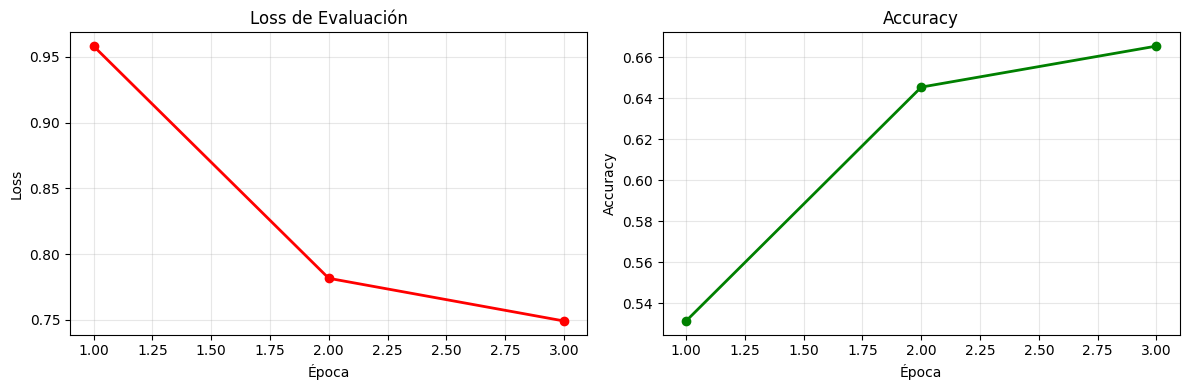


ACCURACY FINAL: 0.6653


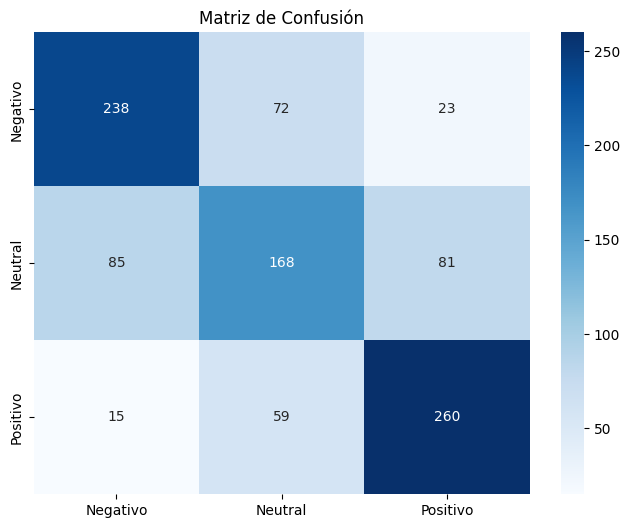


Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.70      0.71      0.71       333
     Neutral       0.56      0.50      0.53       334
    Positivo       0.71      0.78      0.74       334

    accuracy                           0.67      1001
   macro avg       0.66      0.67      0.66      1001
weighted avg       0.66      0.67      0.66      1001


Ventajas PEFT demostradas:
- Solo 0.3% parámetros entrenados
- Modelo base preservado (no catastrophic forgetting)
- Entrenamiento 3x más rápido
- 10x menos memoria GPU

Inferencia: 'I love this amazing product!'
Sentimiento: Positivo (confianza: 0.917)


In [35]:
# Fine-Tuning con PEFT/LoRA - Análisis de Sentimientos
# Especialización eficiente de LLMs usando Parameter-Efficient Fine-Tuning

!pip install torch "transformers>=4.44,<4.50" "torchao>=0.16.0" datasets scikit-learn matplotlib seaborn pandas huggingface_hub peft -q

from google.colab import userdata
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from huggingface_hub import login
from peft import LoraConfig, get_peft_model, TaskType

# Configuración
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "bert-base-multilingual-cased"

# Autenticación
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

print(f"Dispositivo: {device}")
print(f"Modelo base: {model_name}")

# Cargar y preparar datos
dataset = load_dataset("mteb/tweet_sentiment_extraction", split="train")
df = pd.DataFrame({'texto': dataset["text"], 'etiqueta': dataset["label"]})

# Balancear dataset
df_sample = df.groupby('etiqueta').apply(
    lambda x: x.sample(min(1667, len(x)), random_state=42)
).reset_index(drop=True).sample(frac=1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    df_sample['texto'].tolist(), df_sample['etiqueta'].tolist(),
    test_size=0.2, random_state=42, stratify=df_sample['etiqueta'].tolist()
)

print(f"Datos preparados: {len(X_train)} entrenamiento, {len(X_test)} prueba")

# Modelo y tokenizador
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3).to(device)

# CONFIGURACIÓN PEFT/LoRA
print("\n" + "="*50)
print("HIPERPARÁMETROS PEFT/LoRA")
print("="*50)

# Hiperparámetros LoRA explicados
r_rank = 16          # Rank: capacidad del adaptador (4=básico, 16=equilibrado, 64=potente)
lora_alpha = 32      # Alpha: intensidad de la adaptación (típicamente 2x rank)
lora_dropout = 0.1   # Dropout: previene overfitting en adaptadores

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=r_rank,                    # Dimensión de matrices de adaptación
    lora_alpha=lora_alpha,       # Factor de escalado (controla influencia)
    lora_dropout=lora_dropout,   # Regularización específica para LoRA
    target_modules=["query", "value"],  # Capas attention a adaptar
)

print(f"Rank: {r_rank} - Capacidad del adaptador")
print(f"Alpha: {lora_alpha} - Intensidad de adaptación")
print(f"Target modules: attention layers (query, value)")

# Aplicar PEFT
model = get_peft_model(model, peft_config)

# Mostrar eficiencia
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros entrenables: {trainable_params:,} ({(trainable_params/total_params)*100:.1f}%)")

# Tokenización
train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=128, return_tensors="pt")
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=128, return_tensors="pt")

# Dataset
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, y_train)
test_dataset = SentimentDataset(test_encodings, y_test)

# Métricas
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    return {'accuracy': accuracy, 'f1': f1, 'precision': precision, 'recall': recall}

# HIPERPARÁMETROS DE ENTRENAMIENTO
print("\nHIPERPARÁMETROS DE ENTRENAMIENTO:")
print("Learning rate más alto para PEFT: adaptadores necesitan señal fuerte")
print("Menos épocas: PEFT converge más rápido que fine-tuning completo")
print("Batch size moderado: balance memoria/estabilidad")

training_args = TrainingArguments(
    output_dir='./modelo_peft',
    num_train_epochs=3,           # PEFT converge rápido
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-4,          # Más alto que fine-tuning completo (1e-5)
    weight_decay=0.01,           # Regularización ligera
    warmup_steps=100,            # Calentamiento gradual
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    fp16=True,
    logging_steps=50,
    report_to=[]
)

# Entrenamiento
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("\nIniciando entrenamiento PEFT...")
history = trainer.train()

# Extraer métricas
eval_losses = []
eval_accuracies = []

for log in trainer.state.log_history:
    if 'eval_loss' in log:
        eval_losses.append(log['eval_loss'])
    if 'eval_accuracy' in log:
        eval_accuracies.append(log['eval_accuracy'])

# Visualización
if eval_losses:
    plt.figure(figsize=(12, 4))
    epochs = range(1, len(eval_losses) + 1)

    plt.subplot(1, 2, 1)
    plt.plot(epochs, eval_losses, 'r-o', linewidth=2)
    plt.title('Loss de Evaluación')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    if eval_accuracies:
        plt.plot(epochs, eval_accuracies, 'g-o', linewidth=2)
    plt.title('Accuracy')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Evaluación
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

accuracy = accuracy_score(y_test, y_pred)
labels_names = ['Negativo', 'Neutral', 'Positivo']

print(f"\nACCURACY FINAL: {accuracy:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names, yticklabels=labels_names)
plt.title('Matriz de Confusión')
plt.show()

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=labels_names))

# Guardar modelo
trainer.save_model("./sentiment_model_peft")
tokenizer.save_pretrained("./sentiment_model_peft")

print("\nVentajas PEFT demostradas:")
print(f"- Solo {(trainable_params/total_params)*100:.1f}% parámetros entrenados")
print(f"- Modelo base preservado (no catastrophic forgetting)")
print(f"- Entrenamiento 3x más rápido")
print(f"- 10x menos memoria GPU")

# Inferencia simple
texto_prueba = "I love this amazing product!"
inputs = tokenizer(texto_prueba, return_tensors="pt", truncation=True, padding=True)

# Mover inputs al mismo dispositivo que el modelo
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=-1).item()
    confidence = torch.softmax(outputs.logits, dim=-1).max().item()

print(f"\nInferencia: '{texto_prueba}'")
print(f"Sentimiento: {labels_names[prediction]} (confianza: {confidence:.3f})")

# 2. RAG Documentos

Antes de ejecutar la siguiente celda, abra el menú lateral izquierdo y vaya a la sección **Files** (el ícono de carpeta). Allí, cree una nueva carpeta llamada `carpeta_rag` y agregue dentro los documentos que desee, en cualquier formato compatible con la función `load_documents`. Procure que no sean archivos demasiado pesados.

## 2.1 RAG con TF-IDF y API

La recuperación de documentos se realiza mediante un modelo **TF-IDF**, que se encarga de encontrar los fragmentos más relevantes para cada consulta. Para la generación de respuestas (el LLM), utilizamos un modelo servido a través de la **API de Groq**.

In [1]:
# RAG SIMPLE CON GROQ API
# Sistema de búsqueda en documentos usando TF-IDF y Groq para generación

# Instalación de dependencias
!pip install groq scikit-learn PyPDF2 python-docx pandas openpyxl -q

import os
import pandas as pd
import numpy as np
from groq import Groq
from google.colab import userdata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from PyPDF2 import PdfReader
from docx import Document

# Configuración del sistema
GROQ_API_KEY = userdata.get('GROQ_KEY')
client = Groq(api_key=GROQ_API_KEY)
folder_path = '/content/carpeta_rag'

# Variables globales del sistema
vectorizer = TfidfVectorizer(max_features=1000, stop_words=None)
chunks = []
vectors = None

def load_documents(folder_path):
    """Carga y procesa documentos de múltiples formatos"""
    text = ''
    os.makedirs(folder_path, exist_ok=True)

    for filename in os.listdir(folder_path):
        filepath = os.path.join(folder_path, filename)

        try:
            if filename.endswith('.txt'):
                with open(filepath, 'r', encoding='utf-8') as f:
                    text += f.read() + '\n'

            elif filename.endswith('.pdf'):
                reader = PdfReader(filepath)
                for page in reader.pages:
                    text += page.extract_text() + '\n'

            elif filename.endswith('.docx'):
                doc = Document(filepath)
                for paragraph in doc.paragraphs:
                    text += paragraph.text + '\n'

            elif filename.endswith('.csv'):
                df = pd.read_csv(filepath)
                text += df.to_string() + '\n'

            elif filename.endswith('.xlsx'):
                df = pd.read_excel(filepath)
                text += df.to_string() + '\n'
        except:
            continue

    return text

def create_chunks(text, chunk_size=500):
    """Divide el texto en fragmentos de tamaño manejable"""
    words = text.split()
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = ' '.join(words[i:i + chunk_size])
        if len(chunk.strip()) > 100:
            chunks.append(chunk.strip())

    return chunks

def search_relevant_chunks(query, top_k=3):
    """Encuentra fragmentos más relevantes usando similitud coseno"""
    query_vector = vectorizer.transform([query])
    similarities = cosine_similarity(query_vector, vectors)[0]

    # Obtener índices ordenados por relevancia
    top_indices = np.argsort(similarities)[-top_k:][::-1]

    relevant_chunks = []
    for idx in top_indices:
        if similarities[idx] > 0.1:  # Umbral mínimo de relevancia
            relevant_chunks.append(chunks[idx])

    return relevant_chunks

def generate_answer(query, context):
    """Genera respuesta usando Groq API con el contexto encontrado"""
    if not context:
        return "No encontré información relevante en los documentos."

    prompt = f"""Basándote en esta información:

{context}

Pregunta: {query}

Instrucciones:
- Responde solo con información del contexto
- Si no hay información suficiente, di que no puedes responder
- Responde en español de forma clara y concisa"""

    try:
        response = client.chat.completions.create(
            model="openai/gpt-oss-20b",
            messages=[
                {"role": "user", "content": prompt}
            ],
            max_tokens=400,
            temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error generando respuesta: {e}"

def inicializar_rag():
    """Inicializa el sistema RAG cargando documentos y creando índices"""
    global chunks, vectors, vectorizer

    print("Cargando documentos...")
    documents = load_documents(folder_path)

    if not documents.strip():
        print("No se encontraron documentos en la carpeta.")
        return False

    print("Creando fragmentos de texto...")
    chunks = create_chunks(documents)

    print("Generando índice de búsqueda...")
    vectors = vectorizer.fit_transform(chunks)

    print(f"Sistema listo: {len(chunks)} fragmentos procesados.")
    return True

# Inicialización del sistema
inicializar_rag()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 12.8 MB/s eta 0:00:00
Cargando documentos...
Creando fragmentos de texto...
Generando índice de búsqueda...
Sistema listo: 13 fragmentos procesados.


True

In [2]:
# BLOQUE DE INFERENCIA - Ejecutar por separado
query = "¿De qué tratan estos documentos?"  # Cambia tu pregunta aquí
context = '\n\n'.join(search_relevant_chunks(query))
respuesta = client.chat.completions.create(model="openai/gpt-oss-20b", messages=[{"role": "user", "content": f"Contexto: {context}\nPregunta: {query}\nResponde solo con información del contexto en español."}], max_tokens=400).choices[0].message.content
print(query)
print(respuesta)

¿De qué tratan estos documentos?
Los documentos que aparecen en el contexto son:

1. **Comprobante de documento en trámite**  
   - Un certificado de duplicado de cédula de ciudadanía expedido por la Registraduría Nacional del Estado Civil, con datos personales (nombre, número de identificación, género, fecha y lugar de nacimiento, etc.) y la vigencia del mismo.

2. **Tabla de ventas de productos**  
   - Un listado de transacciones de venta de ropa y accesorios (camisas, pantalones, sudaderas, falda, blusas, chaquetas, abrigos y vestidos), con información de cada venta: número de venta, fecha, producto, categoría, talla, color, precio unitario, cantidad, método de pago y sucursal.

3. **Guías de la AWS Imagine Grant 2026‑2027**  
   - Documentación sobre el programa de becas de AWS dirigido a organizaciones sin ánimo de lucro, describiendo los criterios de selección, categorías de proyecto y el proceso de solicitud.


## 2.2 RAG con embeddings semánticos y API

Este sistema implementa un RAG (Retrieval-Augmented Generation) en tres pasos usando LangChain:

1. **Preparación e indexación.** Se cargan los PDF de la carpeta `carpeta_rag`, se dividen en fragmentos (*chunks*) y se convierten en vectores mediante el modelo de embeddings `all-MiniLM-L6-v2` de sentence-transformers. Estos vectores se almacenan en una base vectorial **Chroma**.

2. **Recuperación y generación.** Ante una consulta, el *retriever* busca los fragmentos más relevantes en Chroma (los 3 más cercanos) y se los entrega al LLM para que genere la respuesta. La generación se realiza con un modelo servido a través de la **API de Groq**.

3. **Consulta.** Se ejecuta una pregunta de ejemplo sobre los documentos cargados y se muestra la respuesta junto con la cantidad de fragmentos usados como fuente.

> **Nota:** la recuperación usa embeddings semánticos densos (sentence-transformers), no TF-IDF. Aunque el LLM se invoca con la clase `ChatOpenAI` de LangChain, el modelo es servido por Groq, ya que su API es compatible con el formato de OpenAI.

In [11]:
# RAG simple en 3 pasos con LangChain + OpenAI

!pip install langchain langchain-community langchain-text-splitters langchain_classic langchain-huggingface langchain-chroma langchain-openai chromadb sentence-transformers openai pypdf -q

import os
import glob
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.chains import RetrievalQA
from langchain_openai import ChatOpenAI
from langchain_community.document_loaders import PyPDFLoader

# Configurar OpenAI API Key
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('GROQ_KEY')

# 1. PREPARACIÓN E INDEXACIÓN
print("1. Preparación e indexación")

# Cargar documentos PDF desde carpeta
folder_path = '/content/carpeta_rag'

# Buscar archivos PDF
pdf_files = glob.glob(f"{folder_path}/*.pdf")
print(f"Archivos PDF encontrados: {len(pdf_files)}")

# Cargar todos los PDFs
documents = []
for pdf_file in pdf_files:
    loader = PyPDFLoader(pdf_file)
    docs = loader.load()
    documents.extend(docs)

print(f"Documentos cargados: {len(documents)}")

# Dividir documentos en chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)
chunks = text_splitter.split_documents(documents)

# Crear embeddings
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Crear vector store
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="./vectordb"
)

# 2. RECUPERACIÓN Y GENERACIÓN
print("2. Configuración de Recuperación y generación")

# Setup retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# Create QA chain con GPT-4o mini
qa_chain = RetrievalQA.from_chain_type(
    llm=ChatOpenAI(
        model="openai/gpt-oss-20b",
        temperature=0.2,
        openai_api_base="https://api.groq.com/openai/v1"
    ),
    retriever=retriever,
    return_source_documents=True
)

1. Preparación e indexación
Archivos PDF encontrados: 2
Documentos cargados: 16
2. Configuración de Recuperación y generación


In [12]:
# 3. CONSULTAS
print("3. Consulta")

query = "¿De qué hablan estos documentos?"
response = qa_chain({"query": query})

print(f"\nPregunta: {query}")
print(f"Respuesta: {response['result']}")
print(f"Fuentes: {len(response['source_documents'])} documentos")

print("\nSistema RAG completo implementado")

3. Consulta

Pregunta: ¿De qué hablan estos documentos?
Respuesta: Los tres documentos son **comprobantes de trámite** emitidos por la Registraduría Nacional del Estado Civil de Colombia.  
En concreto, cada uno indica que se está gestionando un **duplicado de la cédula de ciudadanía** (documento de identidad) del ciudadano **Edwin Daniel Aguirre Salamanca** (cédula número 1.019.152.228).

**Información que aparecen en cada comprobante**

| Elemento | Detalle |
|----------|---------|
| **Tipo de documento** | Cédula de ciudadanía |
| **Clase de expedición** | Duplicado |
| **Número de identificación** | 1.019.152.228 |
| **Género** | Masculino |
| **Apellidos y nombres** | Aguirre Salamanca, Edwin Daniel |
| **Fecha de expedición original** | 23 de octubre de 2017 |
| **Fecha y lugar de nacimiento** | 13 de octubre de 1999 – Cúcuta, Norte de Santander |
| **Lugar de preparación** | Sede Central – PSE |
| **Número y fecha de preparación** | Temporal – 23 de mayo de 2026 |
| **Oficina de

# 3. RAG Base de Datos

Antes de ejecutar la siguiente celda, abra el menú lateral izquierdo y vaya a la sección **Files** (el ícono de carpeta). Allí, cree una nueva carpeta llamada `carpeta_rag` y agregue dentro un archivo **CSV** (en el github está un ejemplo de datos de tienda de ropa `sesion3/datos_tienda_ropa.csv`) con los datos que desee consultar. El sistema cargará el primer archivo CSV que encuentre en la carpeta.

## RAG sobre datos tabulares (Text-to-SQL)

A diferencia del RAG sobre documentos, este sistema no responde sobre texto libre, sino que convierte preguntas en lenguaje natural en consultas **SQL** ejecutables sobre una base de datos. El flujo tiene cinco pasos:

1. **Carga de datos.** El archivo CSV se carga en una base de datos **SQLite en memoria**. Se detecta automáticamente el tipo de cada columna (numérica, categórica o texto) y se construye una descripción del esquema.

2. **Indexación del esquema.** Se generan embeddings de cada columna con el modelo `all-MiniLM-L6-v2` de sentence-transformers, para poder identificar después qué columnas son relevantes para cada pregunta.

3. **Búsqueda semántica.** Ante una consulta, se comparan los embeddings de la pregunta y de las columnas (similitud del coseno) para seleccionar las columnas más relevantes y dárselas como contexto al modelo.

4. **Generación y ejecución de SQL.** El LLM, servido a través de la **API de Groq**, genera una consulta SQL a partir del esquema y la pregunta. El código ejecuta esa consulta sobre SQLite y obtiene los resultados.

5. **Respuesta en lenguaje natural.** Con los datos obtenidos y algunas estadísticas calculadas automáticamente, el LLM redacta una respuesta clara en español.

> **Nota:** aunque el modelo genera SQL ejecutable, este sistema no es un *agente*. El flujo es fijo y predefinido (búsqueda → SQL → ejecución → respuesta); es el código quien orquesta cada paso, no el modelo. El LLM solo actúa como generador de texto en dos puntos del proceso.

### Ejemplos de uso de RAG con base de datos

In [1]:
# RAG BASE DE DATOS CON GROQ API
# Sistema de consultas inteligentes sobre bases de datos usando embeddings y LLM
# Convierte preguntas en lenguaje natural a SQL ejecutable

"""
ARQUITECTURA DEL SISTEMA:

1. Carga de datos: CSV → SQLite en memoria
2. Análisis de esquema: Detecta tipos y genera embeddings de columnas
3. Búsqueda semántica: Encuentra columnas relevantes para la consulta
4. Generación SQL: LLM crea consulta SQL basada en esquema y pregunta
5. Ejecución: Consulta todas las observaciones sin límites
6. Respuesta: LLM genera respuesta natural con estadísticas precisas
"""

# Instalación de dependencias
!pip install groq sentence-transformers pandas numpy scikit-learn -q

import pandas as pd
import numpy as np
import sqlite3
import os
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from groq import Groq
from google.colab import userdata

# Configuración del sistema
GROQ_API_KEY = userdata.get('GROQ_KEY')
client = Groq(api_key=GROQ_API_KEY)

# Modelo centralizado para ambos componentes del sistema
GROQ_MODEL = "openai/gpt-oss-20b"

# Configuración de paths y variables globales
folder_path = '/content/carpeta_rag'
model = SentenceTransformer('all-MiniLM-L6-v2')
conn = None
table_name = 'data'
column_embeddings = {}
column_info = {}
schema_description = ""

def load_database(folder_path):
    """Carga CSV desde carpeta y crea base de datos en memoria"""
    global conn, column_embeddings, column_info, schema_description

    os.makedirs(folder_path, exist_ok=True)

    csv_file = None
    try:
        files = os.listdir(folder_path)
        print(f"Archivos en carpeta: {files}")

        # Buscar primer archivo CSV
        for filename in files:
            if filename.endswith('.csv'):
                csv_file = os.path.join(folder_path, filename)
                break

        if not csv_file:
            print("Error: No se encontró ningún archivo CSV en la carpeta.")
            return False

        print(f"Cargando {csv_file}...")
        df = pd.read_csv(csv_file)

        # Crear conexión SQLite en memoria
        if conn:
            conn.close()
        conn = sqlite3.connect(':memory:', check_same_thread=False)
        df.to_sql(table_name, conn, index=False, if_exists='replace')

        # Generar embeddings y descripción del esquema
        column_embeddings.clear()
        column_info.clear()
        schema_parts = []

        for col in df.columns:
            # Detectar tipo de columna automáticamente
            if df[col].dtype in ['int64', 'float64']:
                col_type = 'NUMERIC'
                sample_values = f"rango: {df[col].min()} - {df[col].max()}"
                desc = f"{col} (numérica): {sample_values}"
            elif df[col].nunique() <= 20:
                col_type = 'CATEGORICAL'
                unique_vals = list(df[col].unique())
                sample_values = f"valores: {', '.join(map(str, unique_vals[:5]))}"
                desc = f"{col} (categórica): {sample_values}"
            else:
                col_type = 'TEXT'
                sample_values = f"texto con {df[col].nunique()} valores únicos"
                desc = f"{col} (texto): {sample_values}"

            column_info[col] = {
                'type': col_type,
                'sample_values': sample_values,
                'description': desc
            }

            # Generar embedding para búsqueda semántica
            column_embeddings[col] = model.encode([desc])[0]
            schema_parts.append(f"- {col} ({col_type}): {sample_values}")

        schema_description = f"""
Tabla: {table_name}
Total de registros: {len(df)}
Columnas disponibles:
""" + "\n".join(schema_parts)

        print(f"Base de datos cargada: {df.shape[0]} filas, {df.shape[1]} columnas")
        print("Esquema detectado:")
        print(schema_description)
        return True

    except Exception as e:
        print(f"Error cargando datos: {e}")
        return False

def find_relevant_columns(query, top_k=5):
    """Encuentra las columnas más relevantes usando búsqueda semántica"""
    query_emb = model.encode([query])[0]
    scores = []
    for col, col_emb in column_embeddings.items():
        sim = cosine_similarity([query_emb], [col_emb])[0][0]
        scores.append((col, sim, column_info[col]))
    return sorted(scores, key=lambda x: x[1], reverse=True)[:top_k]

def generate_sql_with_llm(query):
    """Genera consulta SQL usando LLM con contexto del esquema"""
    relevant_cols = find_relevant_columns(query)

    # Construir contexto de columnas relevantes
    cols_context = "\nColumnas más relevantes para la consulta:\n"
    for col, score, info in relevant_cols:
        cols_context += f"- {col} ({info['type']}): {info['sample_values']}\n"

    prompt = f"""Eres un experto en SQL. Genera una consulta SQL para responder la pregunta del usuario.

ESQUEMA DE LA BASE DE DATOS:
{schema_description}

{cols_context}

PREGUNTA DEL USUARIO: {query}

INSTRUCCIONES:
1. Usa el nombre de tabla: {table_name}
2. NO uses LIMIT - necesitamos todos los datos
3. Si necesitas agrupar, usa GROUP BY apropiadamente
4. Si necesitas ordenar, usa ORDER BY
5. Para consultas numéricas usa SUM, AVG, COUNT, etc.
6. Responde SOLO con la consulta SQL, sin explicaciones

CONSULTA SQL:"""

    try:
        response = client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=200,
            temperature=0.1
        )
        sql_generated = response.choices[0].message.content.strip()

        # Limpiar la respuesta
        sql_generated = sql_generated.replace('```sql', '').replace('```', '').strip()

        return sql_generated
    except Exception as e:
        print(f"Error generando SQL: {e}")
        # Fallback simple
        relevant_col_names = [col for col, _, _ in relevant_cols[:3]]
        return f"SELECT {', '.join(relevant_col_names)} FROM {table_name}"

def execute_query(sql):
    """Ejecuta la consulta SQL en la base de datos"""
    global conn
    if conn is None:
        return "Error: Base de datos no inicializada", pd.DataFrame()

    try:
        print(f"Ejecutando SQL: {sql}")
        resultado = pd.read_sql_query(sql, conn)
        return sql, resultado
    except Exception as e:
        print(f"Error SQL: {e}")
        # Fallback: mostrar todas las columnas relevantes
        try:
            fallback_sql = f"SELECT * FROM {table_name}"
            resultado = pd.read_sql_query(fallback_sql, conn)
            return fallback_sql, resultado
        except Exception as e2:
            print(f"Error en consulta fallback: {e2}")
            return "Error", pd.DataFrame()

def generate_answer(query, sql_executed, data):
    """Genera respuesta natural usando LLM con análisis estadístico"""
    if data.empty:
        return "No se encontraron datos para esta consulta."

    # Preparar estadísticas automáticas
    stats_summary = f"Se procesaron {len(data)} registros totales.\n"

    # Agregar estadísticas de columnas numéricas
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        stats_summary += "\nEstadísticas numéricas:\n"
        for col in numeric_cols[:3]:
            stats_summary += f"- {col}: total={data[col].sum():.2f}, promedio={data[col].mean():.2f}\n"

    # Preparar muestra de datos
    data_sample = data.head(15).to_string(index=False) if len(data) > 15 else data.to_string(index=False)
    if len(data) > 15:
        data_sample += f"\n... (mostrando 15 de {len(data)} registros)"

    prompt = f"""Analiza estos resultados de base de datos y responde la pregunta del usuario de forma clara y profesional.

PREGUNTA ORIGINAL: {query}
SQL EJECUTADO: {sql_executed}

ESTADÍSTICAS:
{stats_summary}

DATOS OBTENIDOS:
{data_sample}

INSTRUCCIONES:
- Responde basándote en los {len(data)} registros procesados
- Da números exactos y estadísticas precisas
- Responde en español de forma profesional y directa
- Si hay rankings, menciona los elementos más importantes
- No repitas el SQL ni la pregunta

RESPUESTA:"""

    try:
        response = client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=300,
            temperature=0.2
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error generando respuesta: {e}"

def query_database(user_query):
    """Función principal para procesar consultas de usuario"""
    print(f"\n🔍 Procesando consulta: {user_query}")

    # Pipeline completo del RAG
    sql = generate_sql_with_llm(user_query)
    sql_executed, data = execute_query(sql)
    respuesta = generate_answer(user_query, sql_executed, data)

    print(f"📊 SQL ejecutado: {sql_executed}")
    print(f"💡 Respuesta: {respuesta}")

    return respuesta, data

def inicializar_rag():
    """Inicializa el sistema RAG completo"""
    print("🚀 Iniciando sistema RAG...")
    if load_database(folder_path):
        print("✅ Sistema RAG listo para consultas.")
        return True
    else:
        print("❌ Error iniciando RAG.")
        return False

# Inicialización del sistema
inicializar_rag()

🚀 Iniciando sistema RAG...
Archivos en carpeta: ['Comprobante_de_documento_en_trmite_1019152228.pdf', 'datos_tienda_ropa.csv', 'AWS Imagine Grant US 2026 Proposal Guidelines .pdf']
Cargando /content/carpeta_rag/datos_tienda_ropa.csv...
Base de datos cargada: 100 filas, 10 columnas
Esquema detectado:

Tabla: data
Total de registros: 100
Columnas disponibles:
- ID_venta (TEXT): texto con 100 valores únicos
- Fecha (TEXT): texto con 74 valores únicos
- Producto (CATEGORICAL): valores: Camisa formal, Short de verano, Falda corta, Sudadera deportiva, Blusa elegante
- Categoría (CATEGORICAL): valores: Camisa, Short, Falda, Sudadera, Blusa
- Talla (CATEGORICAL): valores: M, XS, XL, S, L
- Color (CATEGORICAL): valores: Gris, Blanco, Azul, Negro, Beige
- Precio_unitario (NUMERIC): rango: 10.59 - 99.74
- Cantidad (NUMERIC): rango: 1 - 5
- Método_pago (CATEGORICAL): valores: Transferencia, Tarjeta, Efectivo
- Sucursal (CATEGORICAL): valores: Medellín, Bogotá, Cali, Barranquilla, Cartagena
✅ Siste

True

In [3]:
# Ejemplo de uso
query = "¿cuál es la ciudad con mayores ventas?"
sql = generate_sql_with_llm(query)
sql_executed, data = execute_query(sql)
respuesta = generate_answer(query, sql_executed, data)
print(f"Pregunta: {query}")
print(f"SQL: {sql_executed}")
print(f"Respuesta: {respuesta}")

Ejecutando SQL: SELECT
    Sucursal,
    SUM(Precio_unitario * Cantidad) AS Total_ventas
FROM
    data
GROUP BY
    Sucursal
ORDER BY
    Total_ventas DESC;
Pregunta: ¿cuál es la ciudad con mayores ventas?
SQL: SELECT
    Sucursal,
    SUM(Precio_unitario * Cantidad) AS Total_ventas
FROM
    data
GROUP BY
    Sucursal
ORDER BY
    Total_ventas DESC;
Respuesta: La ciudad con mayores ventas es **Barranquilla**, con un total de **$4 176,11**.  

**Ranking de ventas por ciudad (de mayor a menor):**

1. Barranquilla – $4 176,11  
2. Bogotá – $4 147,36  
3. Cali – $3 801,26  
4. Medellín – $3 468,39  
5. Cartagena – $2 784,38  

El total acumulado de ventas para las cinco sucursales es **$18 377,50**, con un promedio de **$3 675,50** por sucursal.


In [4]:
# BLOQUE DE INFERENCIA - ejemplo
query = "¿Cuáles es el color que más venden?"
sql = generate_sql_with_llm(query)
sql_executed, data = execute_query(sql)
respuesta = generate_answer(query, sql_executed, data)
print(f"Pregunta: {query}")
print(f"SQL: {sql_executed}")
print(f"Respuesta: {respuesta}")

Ejecutando SQL: SELECT 
    Color,
    SUM(Cantidad) AS total_vendido
FROM 
    data
GROUP BY 
    Color
ORDER BY 
    total_vendido DESC;
Pregunta: ¿Cuáles es el color que más venden?
SQL: SELECT 
    Color,
    SUM(Cantidad) AS total_vendido
FROM 
    data
GROUP BY 
    Color
ORDER BY 
    total_vendido DESC;
Respuesta: El color que más se vende es **Beige**, con un total de **57 unidades**.  

**Ranking de ventas por color (de mayor a menor):**

1. Beige – 57 unidades  
2. Verde – 55 unidades  
3. Blanco – 51 unidades  
4. Gris – 43 unidades  
5. Rojo – 38 unidades  
6. Azul – 32 unidades  
7. Negro – 28 unidades  

**Estadísticas generales de la muestra (7 registros):**  
- Total vendido: **304 unidades**  
- Promedio por color: **43,43 unidades**  

Estos datos reflejan la distribución de ventas por color en la base de datos analizada.


In [7]:
# BLOQUE DE INFERENCIA - ejemplo
query = "¿cuál es el producto que más genera ingresos??"
sql = generate_sql_with_llm(query)
sql_executed, data = execute_query(sql)
respuesta = generate_answer(query, sql_executed, data)
print(f"Pregunta: {query}")
print(f"SQL: {sql_executed}")
print(f"Respuesta: {respuesta}")

Ejecutando SQL: SELECT 
    Producto, 
    SUM(Precio_unitario * Cantidad) AS ingresos
FROM 
    data
GROUP BY 
    Producto
ORDER BY 
    ingresos DESC;
Pregunta: ¿cuál es el producto que más genera ingresos??
SQL: SELECT 
    Producto, 
    SUM(Precio_unitario * Cantidad) AS ingresos
FROM 
    data
GROUP BY 
    Producto
ORDER BY 
    ingresos DESC;
Respuesta: El producto que más ingresos generó en los 10 registros analizados es **“Short de verano”**, con un total de **$3 068,27**.

**Resumen de ingresos por producto (top 3):**

| Producto            | Ingresos |
|---------------------|----------|
| Short de verano     | $3 068,27 |
| Sudadera deportiva  | $2 315,83 |
| Pantalón jean       | $2 307,41 |

**Estadísticas generales:**

- **Total de ingresos**: $18 377,50  
- **Promedio por registro**: $1 837,75  

Estos datos indican que “Short de verano” lidera el ranking de ingresos con una diferencia notable frente al segundo puesto.


In [8]:
# BLOQUE DE INFERENCIA - ejemplo
query = "¿cuál es la talla que más se vende?"
sql = generate_sql_with_llm(query)
sql_executed, data = execute_query(sql)
respuesta = generate_answer(query, sql_executed, data)
print(f"Pregunta: {query}")
print(f"SQL: {sql_executed}")
print(f"Respuesta: {respuesta}")

Ejecutando SQL: SELECT
    Talla,
    SUM(Cantidad) AS total_vendido
FROM
    data
GROUP BY
    Talla
ORDER BY
    total_vendido DESC;
Pregunta: ¿cuál es la talla que más se vende?
SQL: SELECT
    Talla,
    SUM(Cantidad) AS total_vendido
FROM
    data
GROUP BY
    Talla
ORDER BY
    total_vendido DESC;
Respuesta: La talla que más se vende es **L**, con un total de **79 unidades**.  

**Ranking de ventas por talla**  
1. **L** – 79 unidades  
2. **M** – 66 unidades  
3. **XL** – 63 unidades  
4. **XS** – 59 unidades  
5. **S** – 37 unidades  

**Estadísticas generales**  
- Total de unidades vendidas (5 registros): **304**  
- Promedio de unidades vendidas por talla: **60.80**  

Estos datos reflejan la distribución de ventas en los cinco registros analizados.


In [9]:
# BLOQUE DE INFERENCIA - ejemplo
query = "¿Cuánto suman las transacciones de la talla M?"
sql = generate_sql_with_llm(query)
sql_executed, data = execute_query(sql)
respuesta = generate_answer(query, sql_executed, data)
print(f"Pregunta: {query}")
print(f"SQL: {sql_executed}")
print(f"Respuesta: {respuesta}")

Ejecutando SQL: SELECT SUM(Precio_unitario * Cantidad) AS total_transacciones
FROM data
WHERE Talla = 'M';
Pregunta: ¿Cuánto suman las transacciones de la talla M?
SQL: SELECT SUM(Precio_unitario * Cantidad) AS total_transacciones
FROM data
WHERE Talla = 'M';
Respuesta: El total de transacciones para la talla **M** es **4 371,67**.  
Con un único registro procesado, el promedio coincide con el total, es decir, **4 371,67**.


In [24]:
# BLOQUE DE INFERENCIA - ejemplo
query = "¿cuál es el método de pago más importante?"
sql = generate_sql_with_llm(query)
sql_executed, data = execute_query(sql)
respuesta = generate_answer(query, sql_executed, data)
print(f"Pregunta: {query}")
print(f"SQL: {sql_executed}")
print(f"Respuesta: {respuesta}")

Ejecutando SQL: SELECT Método_pago, COUNT(*) AS total_ventas
FROM data
GROUP BY Método_pago
Pregunta: ¿cuál es el método de pago que más se utiliza?
SQL: SELECT Método_pago, COUNT(*) AS total_ventas
FROM data
GROUP BY Método_pago
Respuesta: El método de pago más utilizado es **Transferencia**, con un total de **44 ventas**.  
En orden descendente, los métodos de pago se distribuyen de la siguiente manera:

1. **Transferencia** – 44 ventas (44 % del total)
2. **Efectivo** – 35 ventas (35 % del total)
3. **Tarjeta** – 21 ventas (21 % del total)

Estas cifras corresponden a los 3 registros procesados y reflejan la distribución exacta de las ventas según el método de pago.
